In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the dataset (Ensure 'spam.csv' is in this same folder)
# The 'r' before the quotes tells Python to read the path exactly as it is written
df = pd.read_csv(r'C:\Users\sowmy\Downloads\oibsip_taskno4-main\oibsip_taskno4-main\spam.csv', encoding='latin-1')

# Clean up columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5572, 2)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sowmy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sowmy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sowmy\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Remove all non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Tokenize and Lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return ' '.join(cleaned_words)

# Apply the preprocessing to the message column
df['processed_message'] = df['message'].apply(preprocess_text)
df[['message', 'processed_message']].head()

,message,processed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Map labels to numerical values
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['processed_message']
y = df['label']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Features vectorization complete.")

Features vectorization complete.


In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize models
nb_model = MultinomialNB()
lr_model = LogisticRegression(solver='liblinear')

# Train Naive Bayes
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_preds)

# Train Logistic Regression
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"Naive Bayes Accuracy: {nb_acc * 100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")

Naive Bayes Accuracy: 97.31%
Logistic Regression Accuracy: 95.34%


C:\Users\sowmy\AppData\Local\Temp\ipykernel_4800\1484801220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


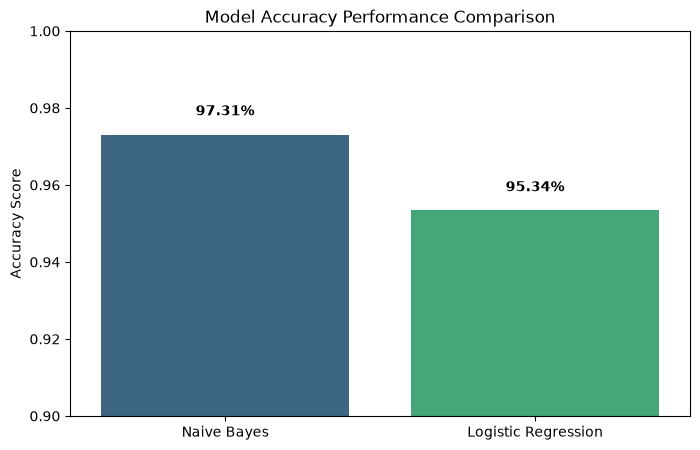

In [6]:
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [nb_acc, lr_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylim(0.90, 1.0)
plt.title('Model Accuracy Performance Comparison')
plt.ylabel('Accuracy Score')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v*100:.2f}%", ha='center', fontweight='bold')
plt.show()

In [7]:
def predict_custom_message(message):
    cleaned = preprocess_text(message)
    vectorized = tfidf.transform([cleaned])
    
    # Using Logistic Regression for final prediction
    prediction = lr_model.predict(vectorized)[0]
    
    if prediction == 1:
        return "🚨 SPAM ALERT!"
    else:
        return "✅ This message looks safe (HAM)."

# Change this text to whatever you want to test!
sample_email = "URGENT! Your mobile number has won a £2,000 cash prize. Call 09061701461 to claim now."
print(f"Message: '{sample_email}'")
print(f"Result: {predict_custom_message(sample_email)}")

Message: 'URGENT! Your mobile number has won a £2,000 cash prize. Call 09061701461 to claim now.'
Result: 🚨 SPAM ALERT!
